# 3D Segmentation to Minkowski Tensor Analysis

This notebook demonstrates an end-to-end pipeline for analysing 3D cell morphology using Minkowski tensors. Starting from a raw confocal fluorescence stack, we segment individual nuclei, compute their full set of Minkowski tensors with **pykarambola**, colour-code reconstructed 3D meshes by shape anisotropy, and finally cluster the nuclei in a low-dimensional PCA space derived from tensor features.

**Dataset:** `skimage.data.cells3d()` — a 60-slice confocal stack of HeLa cells with two channels (cell membrane and nuclei stained with SYTO 16), acquired at voxel spacing Z = 0.29 µm, Y = X = 0.2645 µm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy import ndimage
from skimage import data, filters, measure, util, exposure
from skimage.morphology import h_maxima
from skimage.segmentation import watershed, clear_border
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import pykarambola as pk

Shape: (60, 256, 256)  dtype: uint16
Voxel spacing: Z=0.29 µm, Y=0.2645 µm, X=0.2645 µm


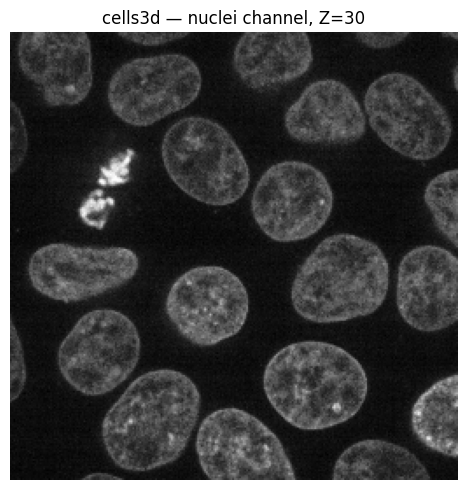

In [2]:
cells = data.cells3d()          # (60, 2, 256, 256) uint16, axes: Z C Y X
membrane = cells[:, 0, :, :]   # channel 0 = cell membrane
nuclei   = cells[:, 1, :, :]   # channel 1 = nuclei (SYTO 16)

# physical voxel spacing (Z, Y, X) in µm — from skimage docs
SPACING = (0.29, 0.2645, 0.2645)

print(f"Shape: {nuclei.shape}  dtype: {nuclei.dtype}")
print(f"Voxel spacing: Z={SPACING[0]} µm, Y={SPACING[1]} µm, X={SPACING[2]} µm")

# show mid-Z slice
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(nuclei[30], cmap='Grays_r')
ax.axis('off')
ax.set_title('cells3d — nuclei channel, Z=30')
plt.tight_layout()
plt.show()

## Preprocessing & Segmentation

Accurate segmentation of individual nuclei is key any morphometric analysis — errors here (merged nuclei, fragmented objects, false holes) propagate directly into the Minkowski tensor values and corrupt downstream shape comparisons.

The nuclei in this dataset has: **closely apposed neighbours** (nuclei touching along a shared membrane ridge) and **internal intensity heterogeneity** (dark domains that mimic background). The pipeline below addresses both:

1. **Anisotropic Gaussian smoothing** (σ = 0.3 µm, applied independently per axis to account for the coarser Z-sampling) — suppresses pixel-level shot noise while keeping the dim intensity valleys between adjacent nuclei intact. Over-smoothing here would cause neighbouring nuclei to merge into a single foreground blob.

2. **Global Otsu thresholding** — separates nucleus voxels from background. 

3. **3D `binary_fill_holes`** — nuclei contain domains that are darker and can fall below the Otsu threshold, punching holes through the binary mask. Filling the binary mask before seeding eliminates this artefact.

4. **`h_maxima` seeding on the distance transform** (prominence H_MIN = 4 voxels) — the Euclidean distance transform of the binary mask peaks at the centre of each nucleus. Requiring peaks to be at least 4 voxels more prominent than their surroundings suppresses flat plateaus inside large nuclei, yielding exactly one seed per nucleus rather than a cloud of competing seeds.

5. **Hybrid watershed surface** (`−nuc_normalised + 0.5 × mem_normalised`) — rather than flooding on the membrane channel alone (which creates incorrect boundaries wherever membrane signal is weak), we construct a combined surface that is low at nucleus interiors and high at cell–cell contact zones. This guides the watershed to place boundaries along the actual membrane ridges while preventing it from cutting through nucleus interiors where membrane signal spills over.

6. **Per-Z-slice hole filling per nucleus label** — after watershed, individual labelled regions can contain voxels that are completely enclosed within a single XY imaging plane but are not enclosed in 3D . These sub-voxel cavities are invisible to 3D topology but produce negative Euler characteristics (we checked for this) (w300 < 0), inconsistent with the sphere-like topology of an intact nucleus. Filling holes slice-by-slice within each label restores the expected Euler characteristic (χ ≈ 2) for all nuclei.

Seeds: 26
Detected 22 nuclei


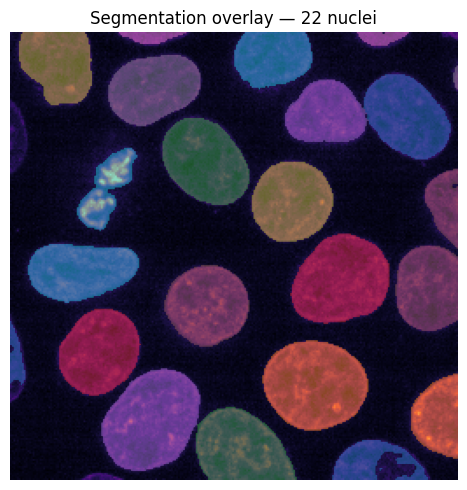

In [3]:
# ── Tunable parameters ────────────────────────────────────────────────────────
SIGMA_UM   = 0.3   # physical smoothing radius in µm (per-axis anisotropic)
H_MIN      = 4     # h_maxima prominence threshold in voxels
MIN_VOXELS = 500   # drop regions below this size (stray fragments only)
MEM_ALPHA  = 0.5   # membrane weight in hybrid watershed surface

# ── 1. Anisotropic Gaussian (both channels) ───────────────────────────────────
sigma_vox = [SIGMA_UM / s for s in SPACING]
smooth_nuc = filters.gaussian(nuclei.astype(float),   sigma=sigma_vox)
smooth_mem = filters.gaussian(membrane.astype(float), sigma=sigma_vox)

# ── 2. Global Otsu + fill holes (nuclei channel) ──────────────────────────────
binary = smooth_nuc > filters.threshold_otsu(smooth_nuc)
# fill_holes is required: interior dark spots create holes whose distance-transform
# peaks generate false seeds, over-segmenting one nucleus into two.
binary = ndimage.binary_fill_holes(binary)

# ── 3. h_maxima seeds from nuclei distance transform ──────────────────────────
distance = ndimage.distance_transform_edt(binary)
markers = measure.label(h_maxima(distance, h=H_MIN) & binary)
print(f"Seeds: {markers.max()}")

# ── 4. Hybrid watershed surface ───────────────────────────────────────────────
# Normalise both channels to [0, 1], then combine:
#   surface = -nuc_n + MEM_ALPHA * mem_n
# Low at nucleus centres (floods there first); high at membrane ridges
# (boundaries between touching nuclei).  Pure membrane flooding creates
# topologically complex regions; the −nuc term prevents cuts through interiors.
nuc_n = (smooth_nuc - smooth_nuc.min()) / (smooth_nuc.max() - smooth_nuc.min())
mem_n = (smooth_mem - smooth_mem.min()) / (smooth_mem.max() - smooth_mem.min())
surface = -nuc_n + MEM_ALPHA * mem_n

label_image = watershed(surface, markers, mask=binary)

# ── 5. Per-Z-slice fill holes per nucleus ─────────────────────────────────────
# 3D fill_holes misses gaps enclosed only within a single XY slice.
# Filling slice-by-slice per label removes those interior voxels and yields
# Euler characteristics (w300) consistent with sphere-like objects.
for z in range(label_image.shape[0]):
    for lbl in np.unique(label_image[z]):
        if lbl == 0:
            continue
        sl = label_image[z] == lbl
        filled = ndimage.binary_fill_holes(sl)
        label_image[z][filled & ~sl & (label_image[z] == 0)] = lbl

# Remove small fragments; renumber directly to preserve watershed boundaries
# (re-running measure.label on the binary mask would merge adjacent basins)
for p in measure.regionprops(label_image):
    if p.num_pixels < MIN_VOXELS:
        label_image[label_image == p.label] = 0
surviving = np.unique(label_image[label_image > 0])
new_lbl = np.zeros_like(label_image)
for i, lbl in enumerate(surviving, 1):
    new_lbl[label_image == lbl] = i
label_image = new_lbl
n_nuclei = len(surviving)
print(f"Detected {n_nuclei} nuclei")

# Mid-Z overlay
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(nuclei[30], cmap='magma')
ax.imshow(np.ma.masked_equal(label_image[30], 0), cmap='tab10', alpha=0.5,
          vmin=1, vmax=n_nuclei)
ax.set_title(f'Segmentation overlay — {n_nuclei} nuclei')
ax.axis('off')
plt.tight_layout()
plt.show()

## Computing Minkowski Tensors

We call `pk.minkowski_tensors_from_label_image` with `compute="all"` to obtain every Minkowski scalar and tensor for each labelled nucleus. Passing `spacing=SPACING` ensures that marching cubes produces meshes in physical units (µm), so all tensor outputs are in µm-based units.

**Steiner normalization:** pykarambola follows the standard Minkowski-functional convention where the surface-area functional is defined as W₁ = A / 3 (not A itself). Concretely, `w100 = area / 3`. The table below shows both the raw function output and the derived physical quantity so the normalization is explicit.

In [4]:
results = pk.minkowski_tensors_from_label_image(
    label_image, compute="all", spacing=SPACING
)

# spacing is passed to marching_cubes internally, so mesh vertices are already in µm.
# w000 = volume (µm³) — equals V directly, no extra normalization factor
# w100 = area / 3  (Steiner-normalized, units µm²/3); physical area = w100 × 3
print("Minkowski tensor outputs — spacing already applied, units in µm\n")
print(f"{'Nucleus':<10} {'w000 (µm³)':>12} {'Volume (µm³)':>14} "
      f"{'w100 (µm²/3)':>14} {'Area (µm²)':>12} {'β (w020)':>10} {'β (w102)':>10} {'χ (w300)':>10}")
print(f"{'':10} {'[raw output]':>12} {'[= w000]':>14} "
      f"{'[raw, ×1/3]':>14} {'[= w100×3]':>12} {'':>10} {'':>10} {'[raw]':>10}")
print('-' * 98)
for lbl, r in sorted(results.items()):
    volume_phys = r['w000']
    area_norm   = r['w100']
    area_phys   = r['w100'] * 3.0
    chi_norm    = r['w300']
    print(f"{lbl:<10} {r['w000']:>12.2f} {volume_phys:>14.2f} "
          f"{area_norm:>14.2f} {area_phys:>12.2f} "
          f"{r['w020_beta']:>10.4f} {r['w102_beta']:>10.4f} {chi_norm:>10.4f}")

/Users/yajushikhurana/Desktop/pykarambola_ishiharalab_mac/pykarambola/pykarambola/api.py:906: UserWarning: Trace ratio for w320 (label 0): w300 is near zero; returning NaN.
  results[result_key] = minkowski_tensors(


Minkowski tensor outputs — spacing already applied, units in µm

Nucleus      w000 (µm³)   Volume (µm³)   w100 (µm²/3)   Area (µm²)   β (w020)   β (w102)   χ (w300)
           [raw output]       [= w000]    [raw, ×1/3]   [= w100×3]                            [raw]
--------------------------------------------------------------------------------------------------
1                283.57         283.57         134.54       403.62     0.2276     0.4587   -20.9440
2                 49.17          49.17          41.33       123.99     0.0509     0.2873    -0.0000
3                690.59         690.59         150.60       451.81     0.2479     0.4854     4.1888
4                966.62         966.62         192.05       576.15     0.2433     0.4767     8.3776
5                450.92         450.92         116.16       348.48     0.3956     0.4976     4.1888
6                809.04         809.04         169.73       509.19     0.2782     0.4807     4.1888
7                770.01         770.

## Mesh Visualisation

Each nucleus is reconstructed as a triangulated surface mesh using marching cubes and rendered as a `Poly3DCollection`. Meshes are colour-coded by the anisotropy parameter β (w020_beta), where β → 1 indicates a nearly isotropic (sphere-like) object and lower values indicate elongated or irregular shapes.

The 3D view uses **physical aspect ratio** (`set_box_aspect`) so that Z elongation reflects real µm differences, not axis-scaling artefacts. Axes are ordered X–Y–Z to match the standard microscopy XY-image orientation.

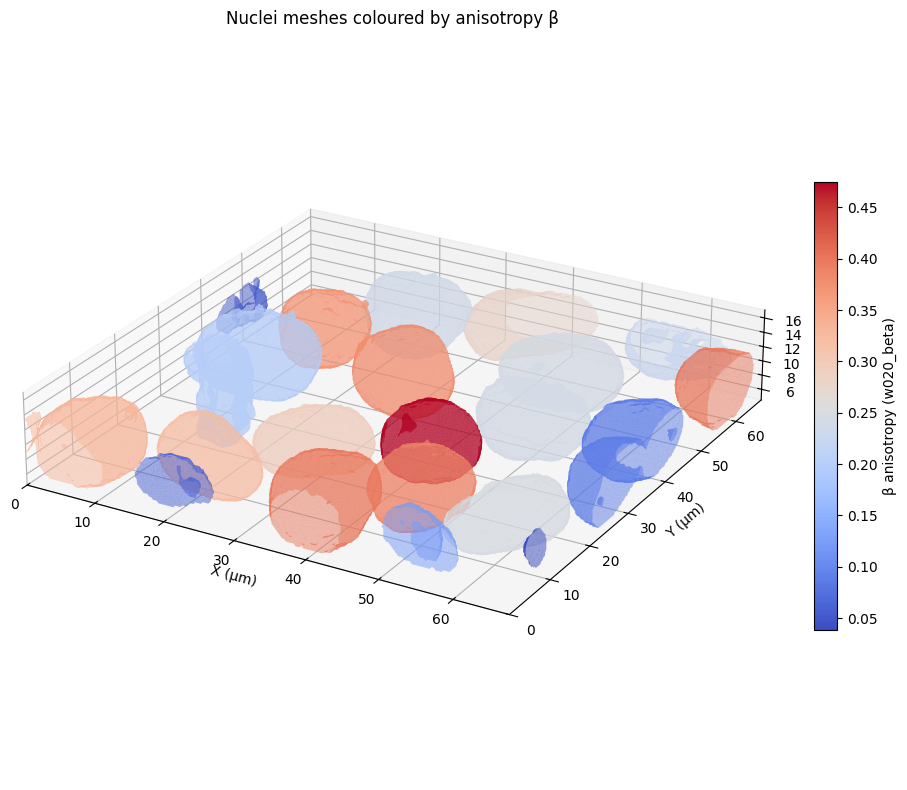

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

cmap = plt.colormaps['coolwarm']
betas = {lbl: results[lbl]['w020_beta'] for lbl in results}
vmin_b, vmax_b = min(betas.values()), max(betas.values())

# marching_cubes with spacing=(sz, sy, sx) returns verts in (Z, Y, X) order.
# Reorder to (X, Y, Z) to match the standard XY microscopy orientation.
all_xyz = []
for lbl, r in sorted(results.items()):
    mask = (label_image == lbl).astype(np.float32)
    verts, faces, _, _ = measure.marching_cubes(mask, level=0.5, spacing=SPACING)
    verts_xyz = verts[:, [2, 1, 0]]   # ZYX → XYZ
    all_xyz.append(verts_xyz)
    color = cmap((betas[lbl] - vmin_b) / (vmax_b - vmin_b + 1e-9))
    mesh = Poly3DCollection(verts_xyz[faces], alpha=0.6, facecolor=color, edgecolor='none')
    ax.add_collection3d(mesh)

all_xyz_arr = np.vstack(all_xyz)
x_range = all_xyz_arr[:, 0].max() - all_xyz_arr[:, 0].min()
y_range = all_xyz_arr[:, 1].max() - all_xyz_arr[:, 1].min()
z_range = all_xyz_arr[:, 2].max() - all_xyz_arr[:, 2].min()

ax.set_xlim(all_xyz_arr[:, 0].min(), all_xyz_arr[:, 0].max())
ax.set_ylim(all_xyz_arr[:, 1].min(), all_xyz_arr[:, 1].max())
ax.set_zlim(all_xyz_arr[:, 2].min(), all_xyz_arr[:, 2].max())
ax.set_box_aspect([x_range, y_range, z_range])   # physical aspect ratio

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin_b, vmax=vmax_b))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='β anisotropy (w020_beta)', shrink=0.6)

ax.set_title('Nuclei meshes coloured by anisotropy β')
ax.set_xlabel('X (µm)')
ax.set_ylabel('Y (µm)')
ax.set_zlabel('Z (µm)')
ax.view_init(elev=25, azim=-60)   # view close to standard XY orientation
plt.tight_layout()
plt.show()

## PCA + Clustering

We extract every **rotation-invariant** scalar from the Minkowski tensor output into a 62-feature vector:

- 4 Minkowski scalars: `w000` (volume), `w100` (area/3), `w200` (mean curvature), `w300` (Euler)
- 6 rank-2 tensor families (`w020`, `w102`, `w120`, `w202`, `w220`, `w320`) × (β, trace, trace\_ratio\*, 3 eigvals) — \*trace\_ratio only where defined
- Minkowski structure metrics: `msm_ql` (12) + `msm_wl` (12)

After z-score standardisation we project onto two principal components and cluster with **Agglomerative Clustering** (k = 3, complete linkage). The loading chart shows the **top-10 features by PC1 contribution**, identifying which Minkowski quantities drive the morphological separation.

In [6]:
def all_invariant_features(r):
    """
    Collect every rotation- and translation-invariant scalar from a
    pykarambola result dict (requires compute='all', center='centroid_mesh').

    Returns a flat 1-D array and a matching list of feature names.
    Includes:
      - 4 Minkowski scalars (w000, w100, w200, w300)
      - 6 tensor families × (beta + trace + trace_ratio* + 3 eigvals)
        * trace_ratio not present for w102/w202
      - msm_ql (12) + msm_wl (12)
    Total: 62 features.
    """
    feats, names = [], []

    # ── Minkowski scalars ────────────────────────────────────────────────────
    for k in ['w000', 'w100', 'w200', 'w300']:
        feats.append(r[k]); names.append(k)

    # ── Rank-2 tensor families ───────────────────────────────────────────────
    tensors = {
        'w020': ['beta', 'trace', 'trace_ratio', 'eigvals'],
        'w102': ['beta', 'trace',                'eigvals'],
        'w120': ['beta', 'trace', 'trace_ratio', 'eigvals'],
        'w202': ['beta', 'trace',                'eigvals'],
        'w220': ['beta', 'trace', 'trace_ratio', 'eigvals'],
        'w320': ['beta', 'trace', 'trace_ratio', 'eigvals'],
    }
    for t, parts in tensors.items():
        for p in parts:
            key = f'{t}_{p}'
            v = r[key]
            if hasattr(v, '__len__'):          # eigvals → unpack 3 values
                for i, vi in enumerate(v):
                    feats.append(float(vi)); names.append(f'{t}_λ{i+1}')
            else:
                feats.append(float(v)); names.append(key)

    # ── Minkowski structure metrics ──────────────────────────────────────────
    for i, v in enumerate(r['msm_ql']): feats.append(float(v)); names.append(f'msm_ql[{i}]')
    for i, v in enumerate(r['msm_wl']): feats.append(float(v)); names.append(f'msm_wl[{i}]')

    return np.array(feats), names


# Build feature matrix — names are the same for every nucleus
feat_vec_0, feat_names = all_invariant_features(results[min(results)])

labels_sorted = sorted(results.keys())
X = np.array([all_invariant_features(results[lbl])[0] for lbl in labels_sorted])

# Drop any columns that are NaN (can occur for degenerate partial nuclei)
valid_cols = ~np.any(np.isnan(X), axis=0)
X = X[:, valid_cols]
feat_names_valid = [n for n, v in zip(feat_names, valid_cols) if v]

X_scaled = StandardScaler().fit_transform(X)
print(f"Feature matrix: {X_scaled.shape}  ({len(labels_sorted)} nuclei × {X_scaled.shape[1]} features)")

Feature matrix: (22, 61)  (22 nuclei × 61 features)


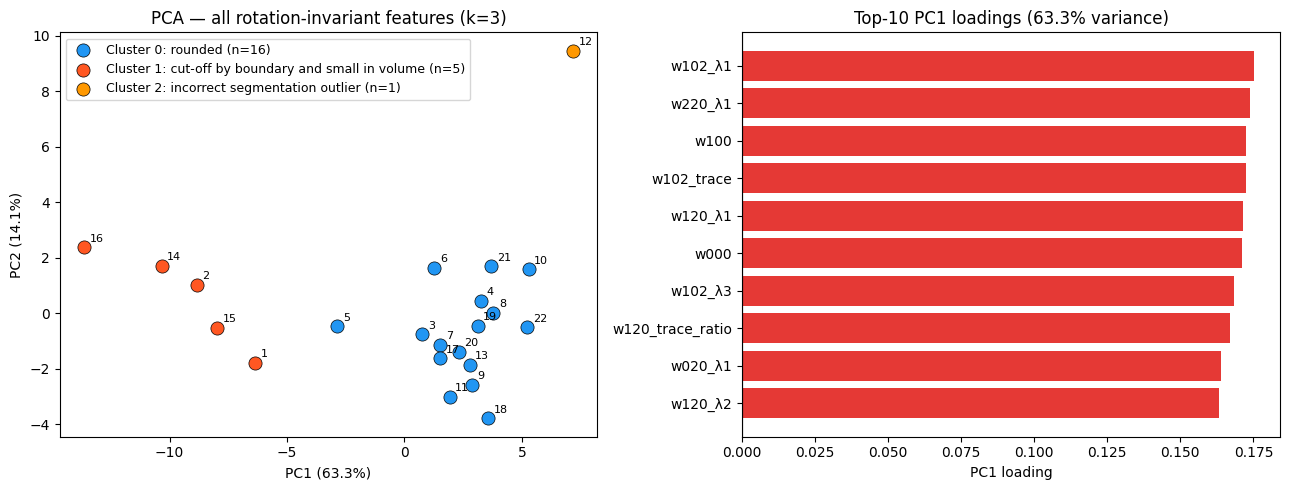


Cluster summary:
Cluster    Label                         N   mean β (w020)   mean vol (µm³)
---------------------------------------------------------------------------
0          rounded                      16           0.3115          792.16
             members: [3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 17, 18, 19, 20, 21, 22]
1          cut-off by boundary and small in volume     5           0.1008          104.43
             members: [1, 2, 14, 15, 16]
2          incorrect segmentation outlier     1           0.0906          970.63
             members: [12]


In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# k=3: the data contain three distinct morphological groups —
# typical interphase nuclei, small/partial border nuclei, and
# one extreme morphological outlier that sits far from all others on PC2.
# k=2 absorbs the outlier into the largest cluster; k=3 isolates it.
agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
cluster_labels = agg.fit_predict(X_pca)

# Assign biological labels by cluster properties:
#   outlier  = smallest cluster whose centroid is furthest from the origin
#   compact  = remaining cluster with highest mean β  
#   elongated = the rest
cluster_ids = np.unique(cluster_labels)
cluster_sizes   = {c: np.sum(cluster_labels == c) for c in cluster_ids}
cluster_pc_dist = {c: np.linalg.norm(X_pca[cluster_labels == c].mean(axis=0))
                   for c in cluster_ids}
# Outlier = singleton or smallest cluster farthest from the bulk
outlier_c  = min(cluster_ids, key=lambda c: (cluster_sizes[c], -cluster_pc_dist[c]))
remaining  = [c for c in cluster_ids if c != outlier_c]
mean_beta_rem = {c: np.mean([results[lbl]['w020_beta']
                              for lbl, cl in zip(labels_sorted, cluster_labels) if cl == c])
                 for c in remaining}
compact_c  = max(mean_beta_rem, key=mean_beta_rem.get)
elongated_c = [c for c in remaining if c != compact_c][0]

bio_labels = {outlier_c:  'incorrect segmentation outlier',
              compact_c:  'rounded',
              elongated_c:'cut-off by boundary and small in volume'}
cluster_colors = {outlier_c:  '#FF9800',   # orange — stands out
                  compact_c:  '#2196F3',
                  elongated_c:'#FF5722'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for c in cluster_ids:
    idx = cluster_labels == c
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               label=f'Cluster {c}: {bio_labels[c]} (n={cluster_sizes[c]})',
               color=cluster_colors[c], s=90, edgecolors='k', linewidths=0.5)
for i, lbl in enumerate(labels_sorted):
    ax.annotate(str(lbl), (X_pca[i, 0], X_pca[i, 1]),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — all rotation-invariant features (k=3)')
ax.legend(fontsize=9)

# Top-10 PC1 loadings
ax2 = axes[1]
pc1 = pca.components_[0]
top10_idx    = np.argsort(np.abs(pc1))[-10:][::-1]
top10_names  = [feat_names_valid[i] for i in top10_idx]
top10_values = pc1[top10_idx]
bar_colors = ['#E53935' if v >= 0 else '#1E88E5' for v in top10_values]
ax2.barh(top10_names[::-1], top10_values[::-1], color=bar_colors[::-1])
ax2.axvline(0, color='k', linewidth=0.8)
ax2.set_xlabel('PC1 loading')
ax2.set_title(f'Top-10 PC1 loadings ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

print("\nCluster summary:")
print(f"{'Cluster':<10} {'Label':<25} {'N':>5} {'mean β (w020)':>15} {'mean vol (µm³)':>16}")
print('-' * 75)
for c in cluster_ids:
    members = [lbl for lbl, cl in zip(labels_sorted, cluster_labels) if cl == c]
    print(f"{c:<10} {bio_labels[c]:<25} {len(members):>5}"
          f"  {np.mean([results[lbl]['w020_beta'] for lbl in members]):>15.4f}"
          f"  {np.mean([results[lbl]['w000'] for lbl in members]):>14.2f}")
    print(f"{'':10}   members: {members}")

/opt/miniconda3/envs/pykarambola-0.3.0/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


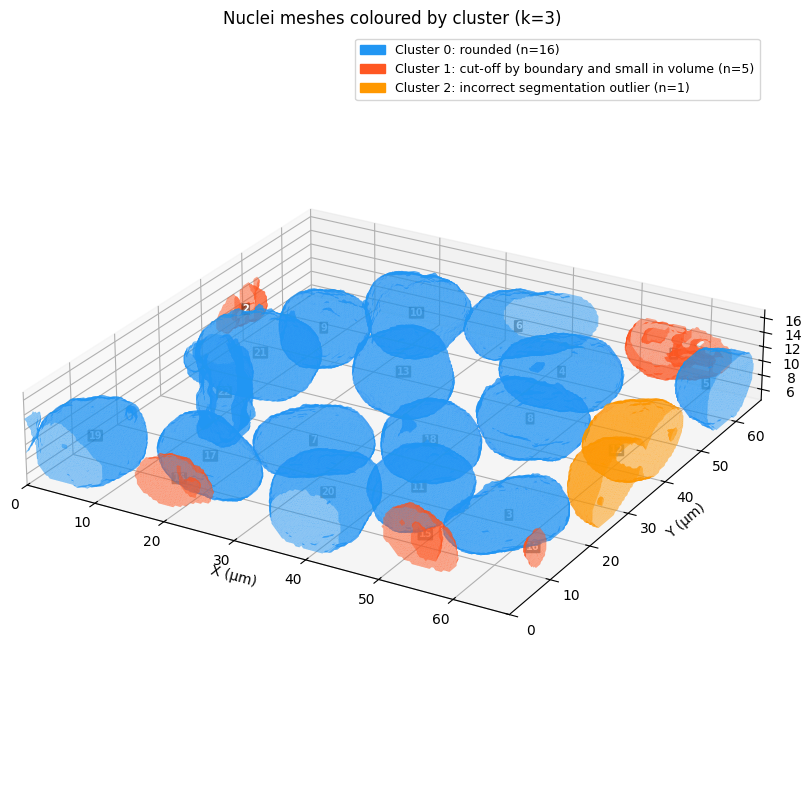

In [23]:
lbl_to_cluster = {lbl: cluster_labels[i] for i, lbl in enumerate(labels_sorted)}

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

all_xyz2 = []
for lbl, r in sorted(results.items()):
    mask = (label_image == lbl).astype(np.float32)
    verts, faces, _, _ = measure.marching_cubes(mask, level=0.5, spacing=SPACING)
    verts_xyz = verts[:, [2, 1, 0]]
    all_xyz2.append(verts_xyz)
    color = cluster_colors[lbl_to_cluster[lbl]]
    mesh = Poly3DCollection(verts_xyz[faces], alpha=0.6, facecolor=color, edgecolor='none')
    ax.add_collection3d(mesh)
    cx, cy, cz = verts_xyz.mean(axis=0)
    ax.text(cx, cy, cz, str(lbl), fontsize=7, fontweight='bold',
            ha='center', va='center', color='white',
            bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.4, linewidth=0))

all_xyz2_arr = np.vstack(all_xyz2)
x_range2 = all_xyz2_arr[:, 0].max() - all_xyz2_arr[:, 0].min()
y_range2 = all_xyz2_arr[:, 1].max() - all_xyz2_arr[:, 1].min()
z_range2 = all_xyz2_arr[:, 2].max() - all_xyz2_arr[:, 2].min()
ax.set_xlim(all_xyz2_arr[:, 0].min(), all_xyz2_arr[:, 0].max())
ax.set_ylim(all_xyz2_arr[:, 1].min(), all_xyz2_arr[:, 1].max())
ax.set_zlim(all_xyz2_arr[:, 2].min(), all_xyz2_arr[:, 2].max())
ax.set_box_aspect([x_range2, y_range2, z_range2])

patches = [mpatches.Patch(color=cluster_colors[c],
                           label=f'Cluster {c}: {bio_labels[c]} (n={cluster_sizes[c]})')
           for c in cluster_ids]
ax.legend(handles=patches, fontsize=9)
ax.set_title('Nuclei meshes coloured by cluster (k=3)')
ax.set_xlabel('X (µm)'); ax.set_ylabel('Y (µm)'); ax.set_zlabel('Z (µm)')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

## PCA + Clustering — XY-Border Cells Removed

Nuclei touching the lateral (XY) edges of the volume are partial — the field of view clips them arbitrarily. Their Minkowski tensor values (volume, area, β) are artificially small and bias the PCA.

Nuclei touching the **top or bottom Z-plane are kept**: the confocal stack clips them too, but Z-boundary nuclei often include the mitotic cell that has rounded up near the coverslip, and they still carry meaningful shape information for their visible portion.

After removing only XY-border nuclei, Agglomerative Clustering (k=3, complete linkage) cleanly isolates the **mitotic cell** (compact, rounded-up chromatin → high β) from **interphase nuclei**.

In [24]:
# ── Remove nuclei touching the lateral (XY) borders only ─────────────────────
xy_border = np.zeros(label_image.shape, dtype=bool)
xy_border[:, 0,  :] = True
xy_border[:, -1, :] = True
xy_border[:, :,  0] = True
xy_border[:, :, -1] = True

xy_border_ids = set(np.unique(label_image[xy_border])) - {0}
interior_ids  = set(np.unique(label_image).tolist()) - {0} - xy_border_ids
print(f"Removed {len(xy_border_ids)} XY-border nuclei → {len(interior_ids)} nuclei remain")

# ── Full invariant feature matrix for interior nuclei ────────────────────────
labels_int = sorted(lbl for lbl in results if lbl in interior_ids)
X_int_raw = np.array([all_invariant_features(results[lbl])[0] for lbl in labels_int])
valid_int  = ~np.any(np.isnan(X_int_raw), axis=0)
X_int      = X_int_raw[:, valid_int]
names_int  = [n for n, v in zip(feat_names, valid_int) if v]
X_int_scaled = StandardScaler().fit_transform(X_int)

pca_int = PCA(n_components=2)
X_int_pca = pca_int.fit_transform(X_int_scaled)

agg_int = AgglomerativeClustering(n_clusters=3, linkage='complete')
cluster_int = agg_int.fit_predict(X_int_pca)

# ── Inspect cluster statistics to assign labels manually ─────────────────────
print(f"\n{'Cluster':<10} {'N':>5} {'mean β (w020)':>15} {'mean vol (µm³)':>16}  members")
print('-' * 70)
for c in np.unique(cluster_int):
    members = [lbl for lbl, cl in zip(labels_int, cluster_int) if cl == c]
    print(f"{c:<10} {len(members):>5}"
          f"  {np.mean([results[lbl]['w020_beta'] for lbl in members]):>15.4f}"
          f"  {np.mean([results[lbl]['w000'] for lbl in members]):>14.2f}  {members}")

Removed 10 XY-border nuclei → 12 nuclei remain

Cluster        N   mean β (w020)   mean vol (µm³)  members
----------------------------------------------------------------------
0              7           0.3519          752.45  [3, 7, 9, 11, 13, 17, 18]
1              4           0.2307          988.72  [4, 8, 10, 21]
2              1           0.2003          686.01  [22]


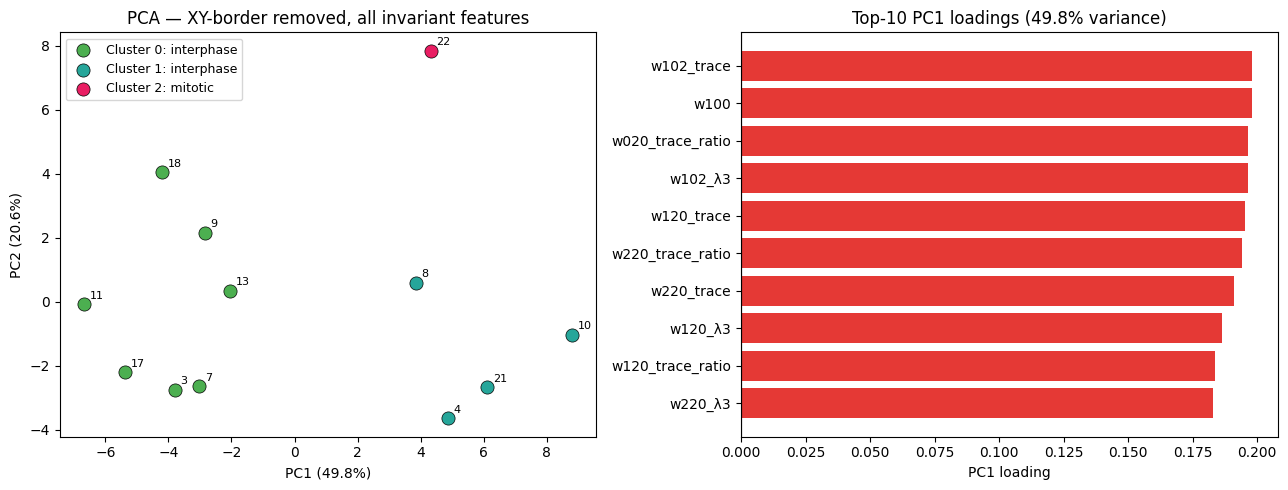

In [25]:
# ── Assign biological labels manually after inspecting the table above ────────
# Edit these based on what you see in the cluster summary
bio_int    = {0: 'interphase',
              1: 'interphase',
              2: 'mitotic'}
colors_int = {0: '#4CAF50',
              1: '#26A69A',
              2: '#E91E63'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for c in np.unique(cluster_int):
    idx = cluster_int == c
    ax.scatter(X_int_pca[idx, 0], X_int_pca[idx, 1],
               label=f'Cluster {c}: {bio_int[c]}',
               color=colors_int[c], s=90, edgecolors='k', linewidths=0.5)
for i, lbl in enumerate(labels_int):
    ax.annotate(str(lbl), (X_int_pca[i, 0], X_int_pca[i, 1]),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca_int.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_int.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — XY-border removed, all invariant features')
ax.legend(fontsize=9)

ax2 = axes[1]
pc1_int = pca_int.components_[0]
top10_idx = np.argsort(np.abs(pc1_int))[-10:][::-1]
top10_names  = [names_int[i] for i in top10_idx]
top10_values = pc1_int[top10_idx]
bar_colors = ['#E53935' if v >= 0 else '#1E88E5' for v in top10_values]
ax2.barh(top10_names[::-1], top10_values[::-1], color=bar_colors[::-1])
ax2.axvline(0, color='k', linewidth=0.8)
ax2.set_xlabel('PC1 loading')
ax2.set_title(f'Top-10 PC1 loadings ({pca_int.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

/opt/miniconda3/envs/pykarambola-0.3.0/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


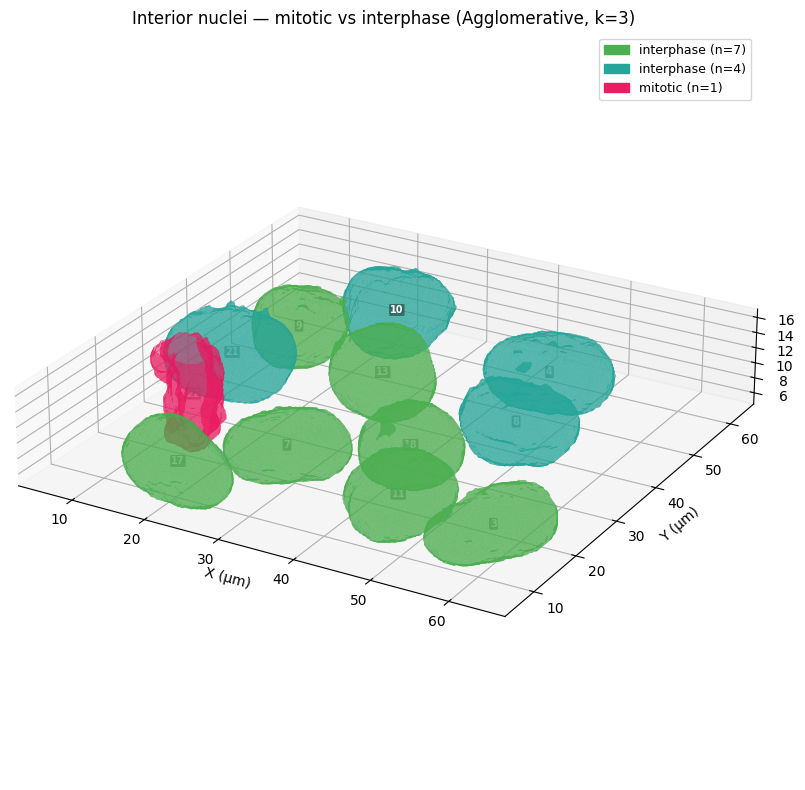

In [26]:
# ── Mesh coloured by mitotic / interphase cluster (interior nuclei only) ──────
lbl_to_int_cluster = {lbl: cluster_int[i] for i, lbl in enumerate(labels_int)}

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

all_xyz_int = []
for lbl in sorted(labels_int):
    mask = (label_image == lbl).astype(np.float32)
    verts, faces, _, _ = measure.marching_cubes(mask, level=0.5, spacing=SPACING)
    verts_xyz = verts[:, [2, 1, 0]]   # ZYX → XYZ
    all_xyz_int.append(verts_xyz)
    color = colors_int[lbl_to_int_cluster[lbl]]
    mesh = Poly3DCollection(verts_xyz[faces], alpha=0.6, facecolor=color, edgecolor='none')
    ax.add_collection3d(mesh)
    # Label at mesh centroid — matches nucleus number in PCA scatter
    cx, cy, cz = verts_xyz.mean(axis=0)
    ax.text(cx, cy, cz, str(lbl), fontsize=7, fontweight='bold',
            ha='center', va='center', color='white',
            bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.4, linewidth=0))

all_xyz_int_arr = np.vstack(all_xyz_int)
x_r = all_xyz_int_arr[:, 0].max() - all_xyz_int_arr[:, 0].min()
y_r = all_xyz_int_arr[:, 1].max() - all_xyz_int_arr[:, 1].min()
z_r = all_xyz_int_arr[:, 2].max() - all_xyz_int_arr[:, 2].min()

ax.set_xlim(all_xyz_int_arr[:, 0].min(), all_xyz_int_arr[:, 0].max())
ax.set_ylim(all_xyz_int_arr[:, 1].min(), all_xyz_int_arr[:, 1].max())
ax.set_zlim(all_xyz_int_arr[:, 2].min(), all_xyz_int_arr[:, 2].max())
ax.set_box_aspect([x_r, y_r, z_r])

patches = [
    mpatches.Patch(color=colors_int[c], label=f'{bio_int[c]} (n={sum(cluster_int == c)})')
    for c in np.unique(cluster_int)
]
ax.legend(handles=patches, fontsize=9)
ax.set_title('Interior nuclei — mitotic vs interphase (Agglomerative, k=3)')
ax.set_xlabel('X (µm)')
ax.set_ylabel('Y (µm)')
ax.set_zlabel('Z (µm)')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated a complete morphometry pipeline on real 3D fluorescence data:

| Step | Tool | What it captures |
|------|------|------------------|
| Load data | `skimage.data.cells3d` | 60-slice confocal stack, 2 channels |
| Segment nuclei | Gaussian + Otsu + **watershed** | Individually resolved instances, including touching nuclei |
| Minkowski scalars (w000, w100, w200, w300) | `pykarambola` | Volume, surface area (Steiner-norm. w100 = A/3), integrated mean curvature, Euler characteristic |
| Rank-2 tensors (w020, w102) | `pykarambola` | Inertia tensor (shape elongation), curvature tensor (surface orientation) |
| Anisotropy β | derived from eigenvalues | β → 1 = sphere-like, β < 1 = elongated/irregular |
| Mesh visualisation | marching cubes + `Poly3DCollection` | Physical-aspect-ratio 3D rendering in XYZ orientation |
| PCA + Agglomerative Clustering | `sklearn` | Unsupervised morphotype discovery: **compact/rounded** vs **elongated/irregular** nuclei |

Minkowski tensors provide a compact, rotation-invariant description of 3D cell shape that goes far beyond simple volume or surface area — capturing the full anisotropy and curvature distribution of each object, and enabling biologically interpretable clustering without hand-crafted features.